# House Price Prediction using Machine Learning

## Project Objective

The objective of this project is to build a Machine Learning model that can predict the selling price of a house based on its features.

In this project, we will use features such as:

- Area of the house
- Number of bedrooms
- Number of bathrooms
- Number of floors
- Parking availability
- Air conditioning
- Furnishing status

We will first understand and preprocess the dataset, then train a Linear Regression model and evaluate its performance.

We will also try a Decision Tree model and compare the two models.

### Machine Learning Workflow

1. Import required libraries
2. Load the dataset
3. Understand the dataset
4. Clean and preprocess the data
5. Select features and target
6. Split the data into training and testing sets
7. Train the model
8. Make predictions
9. Evaluate the model
10. Compare different models
11. Predict the price of a new house

## 1. Import Required Libraries

We will use the following libraries:

- NumPy: Used for numerical computations.
- Pandas: Used for loading, manipulating, and analyzing tabular data.
- Matplotlib: Used for creating visualizations.
- Scikit-learn: Used for splitting data, preprocessing, training models, and evaluating models.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the Dataset

For this project, we will use a House Price dataset containing information about houses and their selling prices.

The dataset should be stored as a CSV file.

The `read_csv()` function from Pandas loads the CSV file into a Pandas DataFrame.

A DataFrame is a table-like structure containing rows and columns.

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("huyngohoang/housingcsv")

print("Path to dataset files:", path)

C:\Users\win10\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 280k/280k [00:00<00:00, 400kB/s]

Extracting files...


Path to dataset files: C:\Users\win10\.cache\kagglehub\datasets\huyngohoang\housingcsv\versions\1


In [7]:
import os

print(os.listdir(path))


['housing.csv']


In [8]:
df = pd.read_csv(os.path.join(path, "housing.csv"))

## 3. Understanding the Dataset

Before building a Machine Learning model, we first need to understand the dataset.

A dataset contains observations arranged in rows and features arranged in columns.

In this project:

- Each row represents one house.
- Each column represents a feature or attribute of a house.
- The `price` column represents the target variable that we want to predict.

We will inspect the shape, column names, data types, and statistical information of the dataset.

In [9]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (5000, 7)


In [10]:
print("Column names:")
print(df.columns)

Column names:
Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [12]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


## 4. Checking for Missing Values

Machine Learning models generally cannot work directly with missing values.

Therefore, before training the model, we need to check whether any column contains missing values.

The `isnull()` function identifies missing values.

The `sum()` function then counts the missing values in each column.

If a column has a value of `0`, it means that the column has no missing values.

In [13]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

## 5. Understanding Data Types

Different columns can contain different types of data.

For example:

- Integer values represent whole numbers.
- Floating-point values represent decimal numbers.
- Object/string values represent categorical information.

Machine Learning algorithms generally require numerical input, so categorical features may need to be converted into numerical representations.

First, we inspect the data types of all columns.

In [14]:
df.dtypes

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

## 6. Viewing the Dataset

We can use Pandas to inspect individual rows of the dataset.

`head()` displays the first five rows by default.

This helps us understand what the actual data looks like before preprocessing it.

In [16]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


We can also look at the last few rows using `tail()`.

In [17]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.94414,7.830362,6.137356,3.46,22837.36103,1060193.786,USNS Williams\nFPO AP 30153-7653
4996,78491.27543,6.999135,6.576763,4.02,25616.11549,1482617.729,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.68689,7.250591,4.805081,2.13,33266.14549,1030729.583,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.33124,5.534388,7.130144,5.44,42625.62016,1198656.872,USS Wallace\nFPO AE 73316
4999,65510.58180,5.992305,6.792336,4.07,46501.28380,1298950.480,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


## 7. Target Variable

In supervised Machine Learning, we have:

- Input features: information given to the model
- Target variable: the value that the model needs to predict

For this project, the target variable is `price`.

The model will learn the relationship between the house features and the house price.

Therefore:

X = input features

y = target variable

In [21]:
df["Price"].describe()

count    5.000000e+03
mean     1.232073e+06
std      3.531176e+05
min      1.593866e+04
25%      9.975771e+05
50%      1.232669e+06
75%      1.471210e+06
max      2.469066e+06
Name: Price, dtype: float64

## 8. Distribution of House Prices

It is useful to visualize the target variable.

A histogram shows how frequently different price ranges occur in the dataset.

This helps us understand the distribution of house prices.


In [20]:
print(df.columns.tolist())

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


In [22]:
features = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population"
]

X = df[features]
y = df["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 5)
y shape: (5000,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 5)
Testing data: (1000, 5)


## 4. Feature Scaling

The features in our dataset have different numerical ranges.

For example:
- Average area income can have large values.
- Number of rooms contains much smaller values.
- House age has another range.
- Area population can also have large values.

When features have very different scales, Gradient Descent can take longer to converge.

To handle this, we use Standardization.

Standardization transforms the features so that they have approximately:
- Mean = 0
- Standard deviation = 1

We will use `StandardScaler` from Scikit-learn.

Important:
- We `fit` the scaler only on the training data.
- We use the same fitted scaler to transform the test data.

This prevents information from the test set from being used while training the model.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (4000, 5)
Scaled testing data shape: (1000, 5)


In [25]:
scaler.fit_transform(X_train)

array([[-0.19049242, -0.12817719, -0.13160635,  0.12038585, -0.82761782],
       [-1.38876401,  0.43080443,  0.80028487, -0.55648895,  1.15829878],
       [-0.35012392,  0.46680752,  1.70375078,  0.03067955, -0.31904298],
       ...,
       [-0.22335061,  0.53809182, -0.36489661, -0.68697084,  0.11908894],
       [-0.92417067,  1.43077434,  2.26846315,  0.2753331 ,  1.39018355],
       [-0.69357335, -0.07762332,  0.89219611,  1.67801341, -0.00681852]],
      shape=(4000, 5))

In [26]:
scaler.transform(X_test)

array([[-0.62396497,  1.05134233, -0.53493732, -0.59726454,  0.77509854],
       [-1.06752524,  0.92593776, -0.05804915, -0.69512596,  0.73880748],
       [ 0.14995479,  0.77674776, -0.31465336, -1.60849918, -0.69076777],
       ...,
       [ 1.16115701,  1.18417775,  0.25662849,  1.18870632,  0.93991305],
       [ 1.69832503,  0.56046124, -1.85607396, -1.54325824,  1.16585758],
       [-0.14145775, -1.04516314,  0.64633546,  0.8625016 , -0.40292631]],
      shape=(1000, 5))

## 5. Building a Linear Regression Model

Linear Regression is a supervised learning algorithm used to predict a continuous numerical value.

In this project, the target variable is `Price`.

The model learns the relationship between the input features and the house price.

Our input features are:

1. Avg. Area Income
2. Avg. Area House Age
3. Avg. Area Number of Rooms
4. Avg. Area Number of Bedrooms
5. Area Population

The model learns a coefficient (weight) for each feature and an intercept.

The general idea is:

Prediction = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

where:
- `x` represents the input features
- `w` represents the learned coefficients
- `b` represents the intercept

In [27]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 6. Understanding Model Coefficients

After training, Linear Regression learns a coefficient for each feature.

A coefficient tells us how the predicted house price changes when that feature changes, while keeping the other features constant.

The model also learns an intercept, which is the baseline value of the prediction.

Because we standardized the features before training, the coefficients represent the effect of a one-standard-deviation change in each feature.

In [29]:
coefficients = linear_model.coef_
intercept = linear_model.intercept_

print("Intercept:", intercept)
print("\nFeature Coefficients:")

for feature, coefficient in zip(features, coefficients):
    print(f"{feature}: {coefficient}")

Intercept: 1229576.9925630253

Feature Coefficients:
Avg. Area Income: 231741.87665386422
Avg. Area House Age: 163580.77656518095
Avg. Area Number of Rooms: 120724.77138500895
Avg. Area Number of Bedrooms: 2992.449136046751
Area Population: 152235.90009854012


## 7. Making Predictions

Now that the Linear Regression model has been trained, we can use it to predict house prices.

We will make predictions on the test dataset.

The model has never seen these test examples during training, so they can be used to evaluate how well the model generalizes to unseen data.

In [30]:
y_pred = linear_model.predict(X_test_scaled)

print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[1308587.92718477 1237037.22950292 1243429.34023015 1228900.21368723
 1063320.90731644 1544058.05050119 1094774.70494245  833284.72338221
  788412.85579589 1469714.86611301]


## 8. Actual vs Predicted Prices

To understand the model's predictions, we can compare:

- Actual Price: the real price from the dataset
- Predicted Price: the price predicted by our model

A smaller difference between actual and predicted values generally indicates a better prediction.

In [31]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1339096.077,1.308588e+06
1,1251794.179,1.237037e+06
2,1340094.966,1.243429e+06
3,1431507.623,1.228900e+06
4,1042373.524,1.063321e+06
5,1555320.500,1.544058e+06
6,1250882.292,1.094775e+06
7,1039380.722,8.332847e+05
8,832475.189,7.884129e+05
9,1420648.281,1.469715e+06


## 9. Model Evaluation

We now evaluate the performance of our Linear Regression model.

We will use four common regression evaluation metrics:

1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. Root Mean Squared Error (RMSE)
4. R² Score

Each metric gives us a different way to understand the model's prediction errors.

### Mean Absolute Error (MAE)

MAE calculates the average absolute difference between the actual prices and predicted prices.

A lower MAE means that, on average, the predictions are closer to the actual values.

The unit of MAE is the same as the target variable, which is the house price.

In [32]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 80879.09722219854


### Mean Squared Error (MSE)

MSE calculates the average of the squared differences between actual and predicted values.

Because the errors are squared, larger errors have a greater effect on the final value.

A lower MSE indicates better model performance.

In [33]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 10089009299.501547


### Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

It is useful because it brings the error back to the same unit as the target variable.

A lower RMSE generally indicates better predictions.

In [34]:
import numpy as np

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 100444.06054865339


### R² Score

R² (R-squared) measures how much of the variation in the target variable can be explained by the model.

For example:

- R² close to 1 → the model explains a large amount of the variation.
- R² close to 0 → the model explains very little of the variation.

For regression, a higher R² is generally better.

In [35]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9179971706985147


In [36]:
print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 80879.09722219854
MSE : 10089009299.501547
RMSE: 100444.06054865339
R²  : 0.9179971706985147


## 10. Actual vs Predicted Prices

A useful way to visualize a regression model is to compare the actual target values with the predicted values.

We will create a scatter plot:

- X-axis → Actual Price
- Y-axis → Predicted Price

We will also draw a reference line where:

Predicted Price = Actual Price

If the model makes perfect predictions, all points would lie exactly on this line.

The closer the points are to the reference line, the better the predictions.

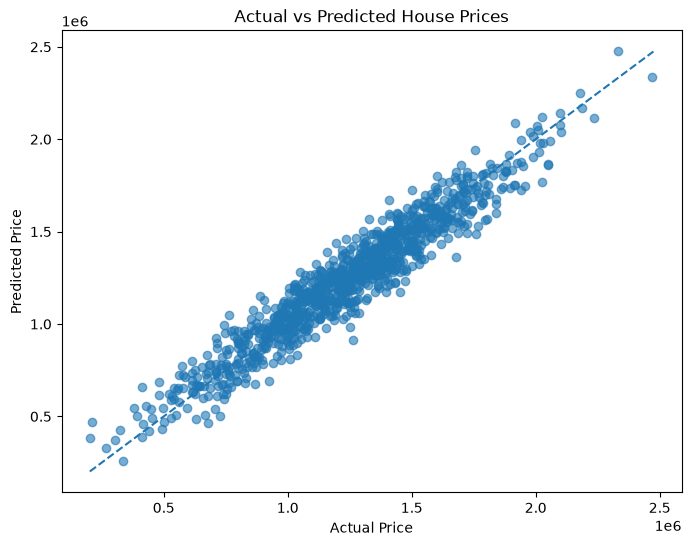

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

## 11. Training vs Testing Performance

A model should perform well not only on the training data but also on unseen test data.

We will calculate the R² score for both:

- Training data
- Testing data

Comparing these scores can help us identify possible overfitting.

If the training score is much higher than the testing score, the model may be overfitting.

If both scores are relatively close, the model is likely generalizing better.

In [38]:
from sklearn.metrics import r2_score

y_train_pred = linear_model.predict(X_train_scaled)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Training R² Score:", train_r2)
print("Testing R² Score:", test_r2)

Training R² Score: 0.9179787435623465
Testing R² Score: 0.9179971706985147


## 12. Decision Tree Regression

A Decision Tree is a supervised learning algorithm that can be used for both classification and regression.

For regression, the tree makes decisions based on feature values and eventually reaches a leaf node containing a predicted numerical value.

Unlike Linear Regression, a Decision Tree does not assume that the relationship between the features and target is linear.

In this project, we will train a Decision Tree Regressor using the same training data and compare its performance with Linear Regression.

In [39]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 13. Decision Tree Predictions

Now we use the trained Decision Tree model to predict house prices for the test dataset.

In [40]:
tree_pred = tree_model.predict(X_test)

print("First 10 Decision Tree predictions:")
print(tree_pred[:10])

First 10 Decision Tree predictions:
[1201236.39129275 1427183.15327238 1470253.23922701 1218786.68610645
 1405713.54075357 1687605.82608    1001668.08426463  748170.26428688
  802591.39083733 1413264.317     ]


## 14. Evaluating the Decision Tree

We will use the same evaluation metrics that we used for Linear Regression:

- MAE
- MSE
- RMSE
- R² Score

Using the same metrics allows us to make a fair comparison between the two models.

In [41]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Evaluation")
print("------------------------")
print("MAE :", tree_mae)
print("MSE :", tree_mse)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree Evaluation
------------------------
MAE : 162811.4630085372
MSE : 42512017979.84423
RMSE: 206184.42710312587
R²  : 0.6544650073981919


## 15. Linear Regression vs Decision Tree

We can now compare the performance of both models.

For MAE, MSE, and RMSE:
- Lower values are generally better.

For R²:
- Higher values are generally better.

In [42]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [mae, tree_mae],
    "MSE": [mse, tree_mse],
    "RMSE": [rmse, tree_rmse],
    "R² Score": [r2, tree_r2]
})

results

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,80879.097222,1.008901e+10,100444.060549,0.917997
1,Decision Tree,162811.463009,4.251202e+10,206184.427103,0.654465


## 16. Predicting the Price of a New House

Our model is now trained and evaluated.

We can use the trained Linear Regression model to predict the price of a new house.

The new house must provide values for the same features that were used during training:

- Avg. Area Income
- Avg. Area House Age
- Avg. Area Number of Rooms
- Avg. Area Number of Bedrooms
- Area Population

Because the Linear Regression model was trained using standardized features, the new input must also be transformed using the same scaler.

In [43]:
new_house = pd.DataFrame({
    "Avg. Area Income": [65000],
    "Avg. Area House Age": [6],
    "Avg. Area Number of Rooms": [7],
    "Avg. Area Number of Bedrooms": [4],
    "Area Population": [35000]
})

new_house_scaled = scaler.transform(new_house)

predicted_price = linear_model.predict(new_house_scaled)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 1141909.9241535657


## 17. Conclusion

In this project, we built a House Price Prediction system using supervised machine learning.

### What We Did

1. Loaded and explored the housing dataset.
2. Identified the input features and target variable.
3. Split the dataset into training and testing sets.
4. Applied feature scaling using StandardScaler.
5. Trained a Linear Regression model.
6. Generated predictions on unseen test data.
7. Evaluated the model using MAE, MSE, RMSE, and R² Score.
8. Visualized actual and predicted prices.
9. Checked training and testing performance.
10. Trained a Decision Tree Regression model.
11. Compared Linear Regression and Decision Tree performance.
12. Used the trained Linear Regression model to predict the price of a new house.

The project demonstrates the complete basic machine learning workflow:

Data → Preprocessing → Training → Prediction → Evaluation → Comparison

# House Price Prediction Using Machine Learning

This project predicts house prices using machine learning techniques.

### Technologies Used

- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook

### Machine Learning Algorithms

- Linear Regression
- Decision Tree Regression

### Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

### Machine Learning Workflow

Dataset
↓
Data Exploration
↓
Feature Selection
↓
Train-Test Split
↓
Feature Scaling
↓
Model Training
↓
Prediction
↓
Model Evaluation
↓
Model Comparison
↓
New House Price Prediction